In [2]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit

sys.path.append("src")
from utils import (THR_GRID, clean_title, load_img, l2n, make_subset, true_matrix,
                   predict_matrix, set_metrics, evaluate, tune_threshold, fuse, sweep_weights)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = "../dataset"
IMG_DIR = f"{DATA_DIR}/train_images"
RES_DIR = "results"
os.makedirs(RES_DIR, exist_ok=True)

N_IMAGES = 10000       # Part C jaisa hi rakho. Pehle 2000 se test run kar sakte ho.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

Device: cpu


In [3]:
full = pd.read_csv(f"{DATA_DIR}/train.csv")
df = make_subset(full, N_IMAGES, SEED)
df["title_clean"] = df["title"].map(clean_title)

gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
va_idx, te_idx = next(gss.split(df, groups=df["label_group"]))

print("Working set:", df.shape, "| groups:", df["label_group"].nunique())
print("val :", len(va_idx), "listings |", df.loc[va_idx, "label_group"].nunique(), "groups")
print("test:", len(te_idx), "listings |", df.loc[te_idx, "label_group"].nunique(), "groups")
print("Group overlap val/test:", len(set(df.loc[va_idx, "label_group"]) & set(df.loc[te_idx, "label_group"])))  # 0

true_v = true_matrix(df["label_group"].values[va_idx])
true_t = true_matrix(df["label_group"].values[te_idx])
print(f"Avg true-set size  val: {true_v.sum(1).mean():.2f} | test: {true_t.sum(1).mean():.2f}")

Working set: (10001, 6) | groups: 3184
val : 4880 listings | 1592 groups
test: 5121 listings | 1592 groups
Group overlap val/test: 0
Avg true-set size  val: 5.47 | test: 6.82


In [4]:
tok_word = dict(token_pattern=r"(?u)\b\w+\b", sublinear_tf=True)
M_word = TfidfVectorizer(**tok_word).fit_transform(df["title_clean"])
M_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2, sublinear_tf=True).fit_transform(df["title_clean"])
print("TF-IDF word:", M_word.shape, "| char:", M_char.shape)

TF-IDF word: (10001, 12234) | char: (10001, 25856)


In [5]:
BS = 64
TIMES = {}

def cached(name, fn):
    path = f"{RES_DIR}/emb_{name}_{len(df)}.npy"
    if os.path.exists(path):
        print(f"{name}: cache se load")
        return np.load(path)
    t0 = time.time()
    E = fn()
    TIMES[name] = round(time.time() - t0, 1)
    np.save(path, E)
    print(f"{name}: {TIMES[name]}s")
    return E

def run_text():
    m = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=DEVICE)
    return m.encode(df["title_clean"].tolist(), batch_size=128, show_progress_bar=True, normalize_embeddings=True)

def run_clip():
    m = SentenceTransformer("clip-ViT-B-32", device=DEVICE)
    out = []
    for s in tqdm(range(0, len(df), BS), desc="CLIP"):
        ims = [load_img(IMG_DIR, f) for f in df["image"].values[s:s + BS]]
        out.append(m.encode(ims, batch_size=BS, convert_to_numpy=True, show_progress_bar=False))
    return np.concatenate(out)

E_txt = l2n(cached("minilm_text", run_text))
E_img = l2n(cached("clip_vitb32_img", run_clip))
json.dump(TIMES, open(f"{RES_DIR}/timings.json", "w"))
print("Text emb:", E_txt.shape, "| Image emb:", E_img.shape)

Batches: 100%|██████████| 79/79 [00:59<00:00,  1.34it/s]


minilm_text: 69.3s


CLIP: 100%|██████████| 157/157 [11:45<00:00,  4.49s/it]

clip_vitb32_img: 712.0s
Text emb: (10001, 384) | Image emb: (10001, 512)


In [6]:
grp = [v[:2] for v in df.groupby("label_group").indices.values() if len(v) >= 2][:2000]
a, b = np.array(grp).T
r = rng.integers(0, len(df), (2, len(a)))
for name, E in [("Text (MiniLM)", E_txt), ("Image (CLIP)", E_img)]:
    same = float((E[a] * E[b]).sum(1).mean()); rand = float((E[r[0]] * E[r[1]]).sum(1).mean())
    print(f"{name:14s} same-group cosine = {same:.3f} | random-pair cosine = {rand:.3f}")
    assert same > rand + 0.05, f"{name} embeddings doesn't match, delete the cache and run again"

Text (MiniLM)  same-group cosine = 0.753 | random-pair cosine = 0.206
Image (CLIP)   same-group cosine = 0.790 | random-pair cosine = 0.456


In [7]:
def sims_for(idx):
    return {
        "word": (M_word[idx] @ M_word[idx].T).toarray().astype(np.float32),
        "char": (M_char[idx] @ M_char[idx].T).toarray().astype(np.float32),
        "emb":  (E_txt[idx] @ E_txt[idx].T).astype(np.float32),
        "clip": (E_img[idx] @ E_img[idx].T).astype(np.float32),
    }

SV, ST = sims_for(va_idx), sims_for(te_idx)

ph = np.array([int(h, 16) for h in df["image_phash"]], dtype=np.uint64)
PH_V = ph[va_idx][:, None] == ph[va_idx][None, :]       # exact pHash match matrices
PH_T = ph[te_idx][:, None] == ph[te_idx][None, :]

n = len(va_idx)
print(f"Matrix size per split: {n}x{n} float32 = {n*n*4/1e6:.0f} MB each, 4 matrices x 2 splits")

Matrix size per split: 4880x4880 float32 = 95 MB each, 4 matrices x 2 splits


In [8]:
RESULTS = []

def report(name, S_val, S_test, force_v=None, force_t=None, note=""):
    thr, f1v = tune_threshold(S_val, true_v, force_v)       # threshold sirf val par
    m = evaluate(S_test, true_t, thr, force_t)
    row = dict(config=name, thr=thr, val_F1=round(f1v, 4), test_P=round(m["precision"], 4),
               test_R=round(m["recall"], 4), test_F1=round(m["f1"], 4), note=note)
    RESULTS.append(row)
    return row

In [9]:
report("Text only (TF-IDF word)", SV["word"], ST["word"])
report("Image only (CLIP)", SV["clip"], ST["clip"])
report("BASELINE: 0.5*TF-IDF word + 0.5*CLIP", fuse(SV["word"], SV["clip"], 0.5), fuse(ST["word"], ST["clip"], 0.5))
pd.DataFrame(RESULTS)

,config,thr,val_F1,test_P,test_R,test_F1,note
0,Text only (TF-IDF word),0.40,0.7970,0.8837,0.7892,0.7893,
1,Image only (CLIP),0.84,0.6706,0.9531,0.5834,0.6640,
2,BASELINE: 0.5*TF-IDF word + 0.5*CLIP,0.56,0.8437,0.9178,0.8288,0.8345,


,w_text,thr,val_F1
0,0.0,0.84,0.6706
1,0.1,0.76,0.7301
2,0.2,0.70,0.7928
3,0.3,0.64,0.8300
4,0.4,0.60,0.8441
5,0.5,0.56,0.8437
6,0.6,0.52,0.8386
7,0.7,0.48,0.8280
8,0.8,0.46,0.8173
9,0.9,0.42,0.8070


Best w_text = 0.4 (val F1 = 0.8441, thr = 0.6)


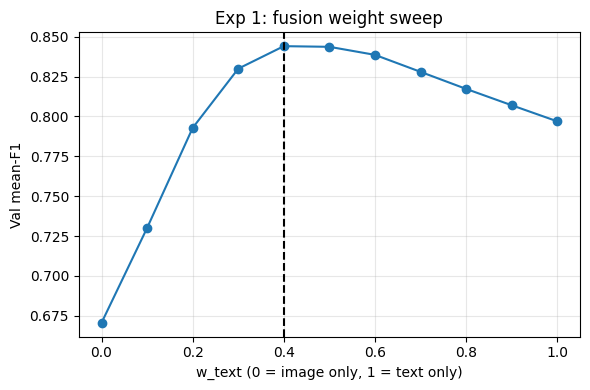

In [10]:
sw1 = sweep_weights(SV["word"], SV["clip"], true_v)
display(sw1.round(4))

best = sw1.loc[sw1.val_F1.idxmax()]
W1 = float(best.w_text)
print(f"Best w_text = {W1} (val F1 = {best.val_F1:.4f}, thr = {best.thr})")
report(f"Exp1: word+CLIP, tuned w={W1}", fuse(SV["word"], SV["clip"], W1), fuse(ST["word"], ST["clip"], W1))

plt.figure(figsize=(6, 4))
plt.plot(sw1.w_text, sw1.val_F1, "o-")
plt.axvline(W1, ls="--", color="k")
plt.xlabel("w_text (0 = image only, 1 = text only)"); plt.ylabel("Val mean-F1")
plt.title("Exp 1: fusion weight sweep"); plt.tight_layout()
plt.savefig(f"{RES_DIR}/exp1_weight_sweep.png", dpi=150); plt.show()

In [11]:
text_variants = {
    "word":        lambda S: S["word"],
    "char":        lambda S: S["char"],
    "MiniLM":      lambda S: S["emb"],
    "char+MiniLM": lambda S: 0.5 * S["char"] + 0.5 * S["emb"],
}

rows, BEST = [], {}
for name, fn in text_variants.items():
    St_v, St_t = fn(SV), fn(ST)
    thr_txt, f1_txt = tune_threshold(St_v, true_v)
    m_txt = evaluate(St_t, true_t, thr_txt)
    sw = sweep_weights(St_v, SV["clip"], true_v)
    b = sw.loc[sw.val_F1.idxmax()]
    m_fus = evaluate(fuse(St_t, ST["clip"], b.w_text), true_t, b.thr)
    BEST[name] = dict(w=float(b.w_text), thr=float(b.thr), val_f1=float(b.val_F1))
    rows.append(dict(text_rep=name, text_only_val_F1=round(f1_txt, 4), text_only_test_F1=round(m_txt["f1"], 4),
                     best_w=float(b.w_text), fused_val_F1=round(float(b.val_F1), 4), fused_test_F1=round(m_fus["f1"], 4),
                     fused_test_P=round(m_fus["precision"], 4), fused_test_R=round(m_fus["recall"], 4)))
exp2 = pd.DataFrame(rows)
exp2.to_csv(f"{RES_DIR}/exp2_text_representations.csv", index=False)

FT = exp2.loc[exp2.fused_val_F1.idxmax(), "text_rep"]        # best text rep (val F1 se)
print("Best text representation for fusion (by val F1):", FT)
exp2

Best text representation for fusion (by val F1): char


,text_rep,text_only_val_F1,text_only_test_F1,best_w,fused_val_F1,fused_test_F1,fused_test_P,fused_test_R
0,word,0.7970,0.7893,0.4,0.8441,0.8305,0.9218,0.8209
1,char,0.8075,0.8086,0.5,0.8515,0.8475,0.8945,0.8675
2,MiniLM,0.6806,0.6756,0.4,0.7760,0.7641,0.9181,0.7354
3,char+MiniLM,0.7875,0.7898,0.5,0.8388,0.8342,0.9010,0.8446


In [12]:
St_v, St_t = text_variants[FT](SV), text_variants[FT](ST)
report(f"Exp2: {FT}+CLIP, tuned w={BEST[FT]['w']}", fuse(St_v, SV["clip"], BEST[FT]["w"]), fuse(St_t, ST["clip"], BEST[FT]["w"]))

{'config': 'Exp2: char+CLIP, tuned w=0.5',
 'thr': 0.58,
 'val_F1': 0.8515,
 'test_P': 0.8945,
 'test_R': 0.8675,
 'test_F1': 0.8475,
 'note': ''}

In [13]:
off = ~np.eye(len(te_idx), dtype=bool)
dup = PH_T & off
print(f"[test] pHash-equal pairs : {dup.sum()//2:,}")
print(f"  purity (same product)  : {(dup & true_t).sum() / max(dup.sum(), 1):.1%}")
print(f"  coverage of true pairs : {(dup & true_t).sum() / (true_t & off).sum():.1%}")

w2 = BEST[FT]["w"]
Sv_fin, St_fin = fuse(St_v, SV["clip"], w2), fuse(St_t, ST["clip"], w2)

row_no = report(f"Exp3a: {FT}+CLIP (no pHash)", Sv_fin, St_fin)
row_ph = report(f"Exp3b: {FT}+CLIP + pHash rule", Sv_fin, St_fin, PH_V, PH_T)
pd.DataFrame([row_no, row_ph])

[test] pHash-equal pairs : 1,781
  purity (same product)  : 99.8%
  coverage of true pairs : 11.9%


,config,thr,val_F1,test_P,test_R,test_F1,note
0,Exp3a: char+CLIP (no pHash),0.58,0.8515,0.8945,0.8675,0.8475,
1,Exp3b: char+CLIP + pHash rule,0.60,0.8538,0.9194,0.8471,0.8478,


In [14]:
use_ph = row_ph["val_F1"] > row_no["val_F1"]
FINAL = dict(text=FT, w=w2, phash=bool(use_ph), thr=row_ph["thr"] if use_ph else row_no["thr"])
force_v = PH_V if use_ph else None
force_t = PH_T if use_ph else None
print("FINAL SYSTEM:", FINAL)

S_text_v, S_text_t = text_variants[FT](SV), text_variants[FT](ST)
S_img_v, S_img_t = SV["clip"], ST["clip"]
S_fin_v, S_fin_t = fuse(S_text_v, S_img_v, FINAL["w"]), fuse(S_text_t, S_img_t, FINAL["w"])
final_metrics = evaluate(S_fin_t, true_t, FINAL["thr"], force_t)
print({k: round(v, 4) for k, v in final_metrics.items()})

FINAL SYSTEM: {'text': 'char', 'w': 0.5, 'phash': True, 'thr': 0.6}
{'precision': 0.9194, 'recall': 0.8471, 'f1': 0.8478}


,Config,Text,Image,pHash,thr,val_F1,test_P,test_R,test_F1
0,A,✓,✗,✗,0.48,0.8075,0.8879,0.8122,0.8086
1,B,✗,✓,✗,0.84,0.6706,0.9531,0.5834,0.6640
2,C,✓,✓,✗,0.58,0.8515,0.8945,0.8675,0.8475
3,D,✓,✓,✓,0.60,0.8538,0.9194,0.8471,0.8478


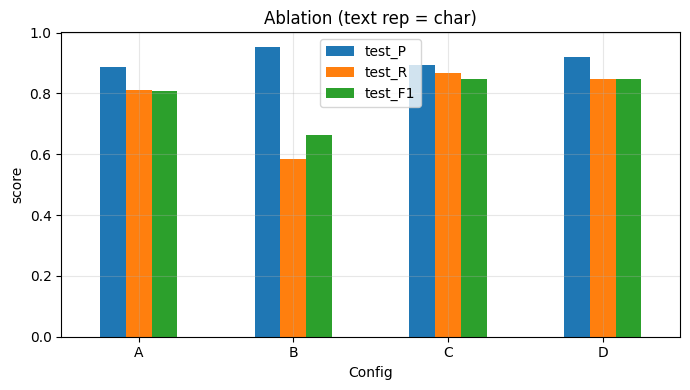

In [15]:
abl_rows = []
def ablate(name, text, image, other, Sv, St, fv=None, ft=None):
    thr, f1v = tune_threshold(Sv, true_v, fv)
    m = evaluate(St, true_t, thr, ft)
    abl_rows.append({"Config": name, "Text": "✓" if text else "✗", "Image": "✓" if image else "✗",
                     "pHash": "✓" if other else "✗", "thr": thr, "val_F1": round(f1v, 4),
                     "test_P": round(m["precision"], 4), "test_R": round(m["recall"], 4), "test_F1": round(m["f1"], 4)})

ablate("A", True,  False, False, S_text_v, S_text_t)
ablate("B", False, True,  False, S_img_v,  S_img_t)
ablate("C", True,  True,  False, S_fin_v,  S_fin_t)
ablate("D", True,  True,  True,  S_fin_v,  S_fin_t, PH_V, PH_T)
abl = pd.DataFrame(abl_rows)
abl.to_csv(f"{RES_DIR}/ablation.csv", index=False)
display(abl)

THR_TEXT_ONLY, THR_IMG_ONLY = abl.loc[0, "thr"], abl.loc[1, "thr"]    # error analysis me kaam aayenge

ax = abl.set_index("Config")[["test_P", "test_R", "test_F1"]].plot.bar(figsize=(7, 4), rot=0)
ax.set_title(f"Ablation (text rep = {FT})"); ax.set_ylabel("score"); plt.tight_layout()
plt.savefig(f"{RES_DIR}/ablation.png", dpi=150); plt.show()

In [16]:
res = pd.DataFrame(RESULTS)
res.to_csv(f"{RES_DIR}/experiment_table.csv", index=False)
res

,config,thr,val_F1,test_P,test_R,test_F1,note
0,Text only (TF-IDF word),0.40,0.7970,0.8837,0.7892,0.7893,
1,Image only (CLIP),0.84,0.6706,0.9531,0.5834,0.6640,
2,BASELINE: 0.5*TF-IDF word + 0.5*CLIP,0.56,0.8437,0.9178,0.8288,0.8345,
3,"Exp1: word+CLIP, tuned w=0.4",0.60,0.8441,0.9218,0.8209,0.8305,
4,"Exp2: char+CLIP, tuned w=0.5",0.58,0.8515,0.8945,0.8675,0.8475,
5,Exp3a: char+CLIP (no pHash),0.58,0.8515,0.8945,0.8675,0.8475,
6,Exp3b: char+CLIP + pHash rule,0.60,0.8538,0.9194,0.8471,0.8478,


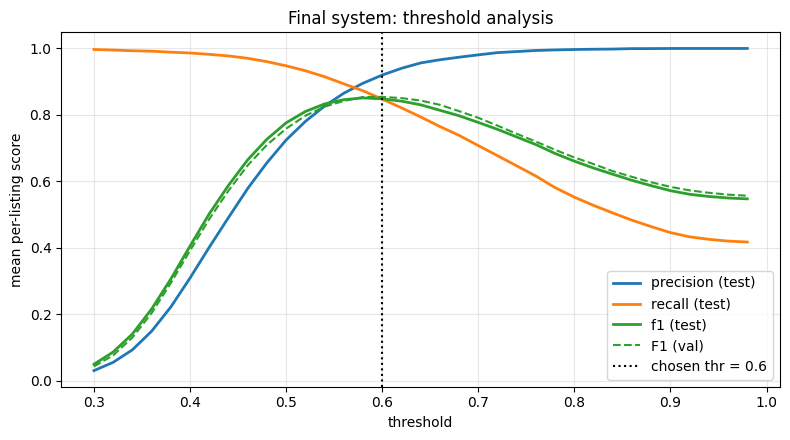

,precision,recall,f1,thr
0,0.7240,0.9472,0.7757,0.5
1,0.9194,0.8471,0.8478,0.6
2,0.9801,0.7073,0.7769,0.7


In [17]:
cv = pd.DataFrame([evaluate(S_fin_v, true_v, t, force_v) for t in THR_GRID], index=THR_GRID)
ct = pd.DataFrame([evaluate(S_fin_t, true_t, t, force_t) for t in THR_GRID], index=THR_GRID)

plt.figure(figsize=(8, 4.5))
for col, c in [("precision", "tab:blue"), ("recall", "tab:orange"), ("f1", "tab:green")]:
    plt.plot(ct.index, ct[col], color=c, lw=2, label=f"{col} (test)")
plt.plot(cv.index, cv["f1"], "--", color="tab:green", label="F1 (val)")
plt.axvline(FINAL["thr"], color="k", ls=":", label=f"chosen thr = {FINAL['thr']}")
plt.xlabel("threshold"); plt.ylabel("mean per-listing score"); plt.title("Final system: threshold analysis")
plt.legend(); plt.tight_layout(); plt.savefig(f"{RES_DIR}/threshold_analysis.png", dpi=150); plt.show()

pd.DataFrame([evaluate(S_fin_t, true_t, t, force_t) | {"thr": t} for t in [FINAL["thr"] - 0.1, FINAL["thr"], FINAL["thr"] + 0.1]]).round(4)

In [18]:
pred_t = predict_matrix(S_fin_t, FINAL["thr"], force_t)
mask = np.triu(np.ones_like(true_t, dtype=bool), k=1)         # har pair ek baar
fp_ij = np.argwhere(pred_t & ~true_t & mask)                   # predicted match, actually different
fn_ij = np.argwhere(~pred_t & true_t & mask)                   # true match, missed
print(f"Pairs  predicted-correct: {(pred_t & true_t & mask).sum():,} | FP: {len(fp_ij):,} | FN: {len(fn_ij):,}")

te_df = df.iloc[te_idx].reset_index(drop=True)

def pair_table(ij):
    i, j = ij[:, 0], ij[:, 1]
    return pd.DataFrame(dict(
        i=i, j=j, s_text=S_text_t[i, j], s_img=S_img_t[i, j], s_fused=S_fin_t[i, j],
        title_i=te_df["title"].values[i], title_j=te_df["title"].values[j],
        img_i=te_df["image"].values[i], img_j=te_df["image"].values[j]))

FP, FN = pair_table(fp_ij), pair_table(fn_ij)
for T in (FP, FN):
    T["text_high"] = T.s_text >= THR_TEXT_ONLY        # kya akela text ise match bolta?
    T["img_high"] = T.s_img >= THR_IMG_ONLY           # kya akeli image ise match bolti?
    T["short_title"] = (T.title_i.str.split().str.len() <= 3) | (T.title_j.str.split().str.len() <= 3)
    nums = lambda s: set(__import__("re").findall(r"\d+", s.lower()))
    T["num_conflict"] = [bool(nums(a)) and bool(nums(b)) and nums(a) != nums(b) for a, b in zip(T.title_i, T.title_j)]

for name, T in [("FALSE POSITIVES", FP), ("FALSE NEGATIVES", FN)]:
    print(f"\n=== {name} (n={len(T):,}): text vs image agreement (% of errors) ===")
    print((pd.crosstab(T.text_high, T.img_high, normalize=True) * 100).round(1)
          .rename(index={True: "text says MATCH", False: "text says DIFFERENT"},
                  columns={True: "image says MATCH", False: "image says DIFFERENT"}))
    print(f"short title (<=3 words): {T.short_title.mean():.1%} | numeric-token conflict: {T.num_conflict.mean():.1%}")

FP.to_csv(f"{RES_DIR}/errors_fp.csv", index=False); FN.to_csv(f"{RES_DIR}/errors_fn.csv", index=False)

Pairs  predicted-correct: 10,125 | FP: 1,194 | FN: 4,771

=== FALSE POSITIVES (n=1,194): text vs image agreement (% of errors) ===
img_high             image says DIFFERENT  image says MATCH
text_high                                                  
text says DIFFERENT                  18.8               5.2
text says MATCH                      71.1               4.9
short title (<=3 words): 10.6% | numeric-token conflict: 35.3%

=== FALSE NEGATIVES (n=4,771): text vs image agreement (% of errors) ===
img_high             image says DIFFERENT  image says MATCH
text_high                                                  
text says DIFFERENT                  74.7               5.2
text says MATCH                      20.1               0.0
short title (<=3 words): 14.4% | numeric-token conflict: 30.5%


FALSE POSITIVE: text HIGH, image LOW (text misleads): 849 pairs


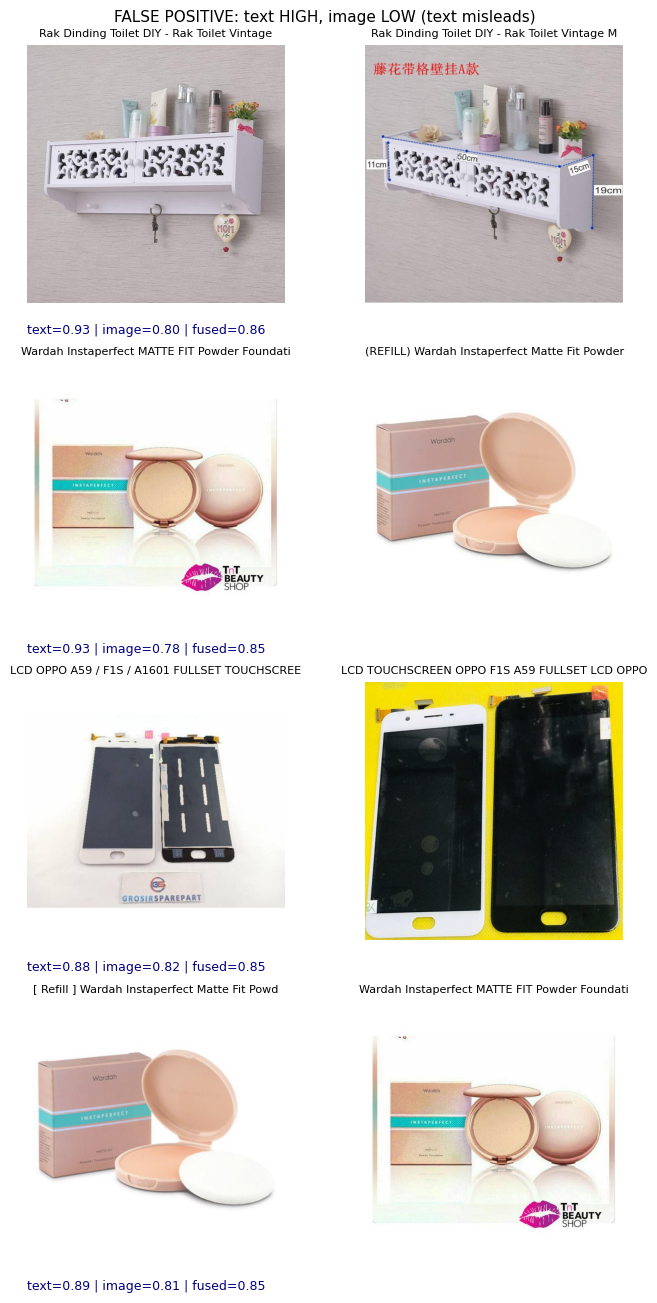

FALSE POSITIVE: text LOW, image HIGH (image misleads): 62 pairs


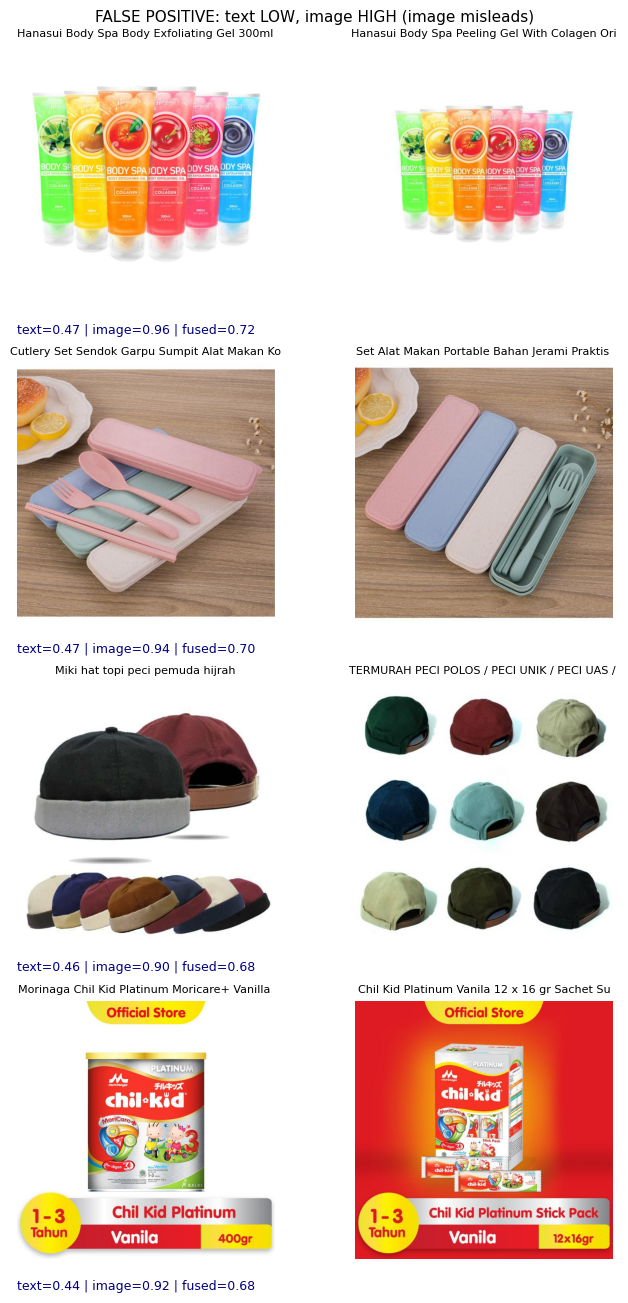

FALSE POSITIVE: BOTH high (near-identical variants): 59 pairs


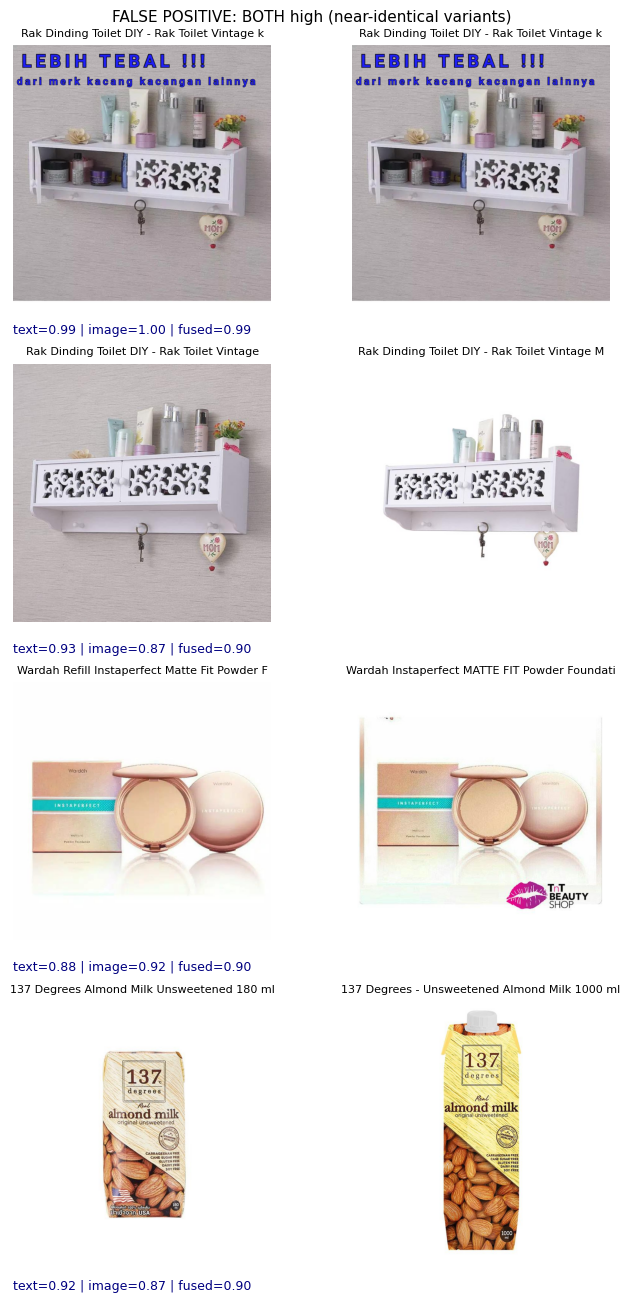

FALSE NEGATIVE: text HIGH, image LOW (image failed): 958 pairs


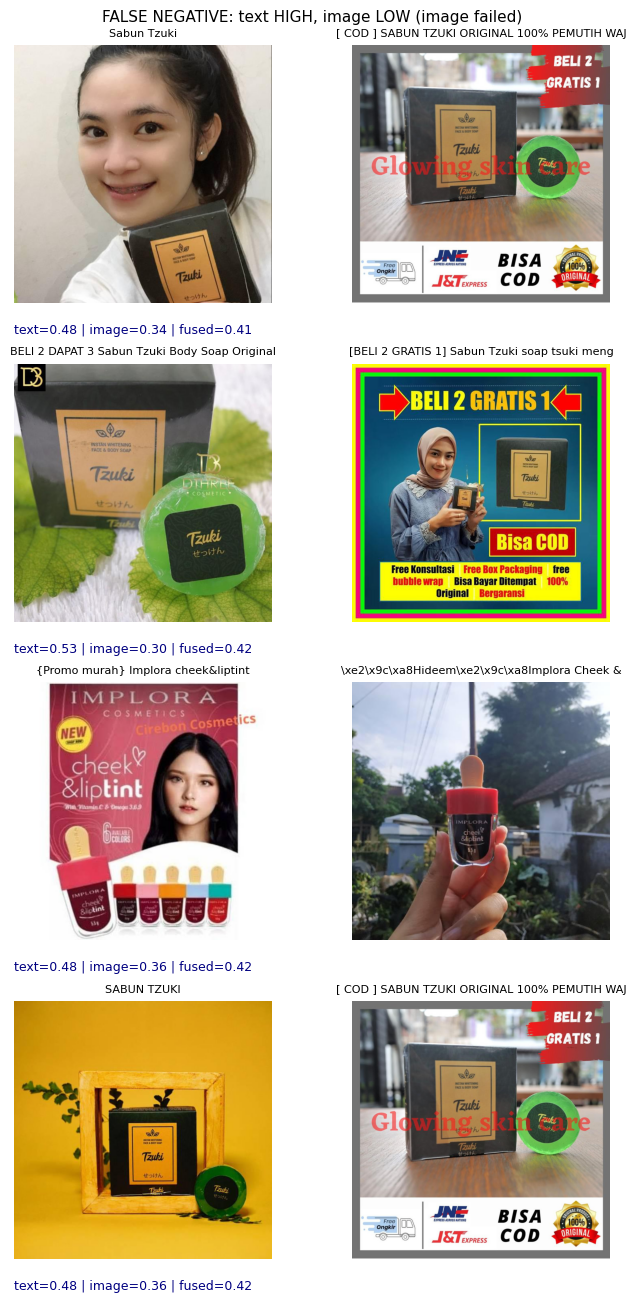

FALSE NEGATIVE: text LOW, image HIGH (text failed): 248 pairs


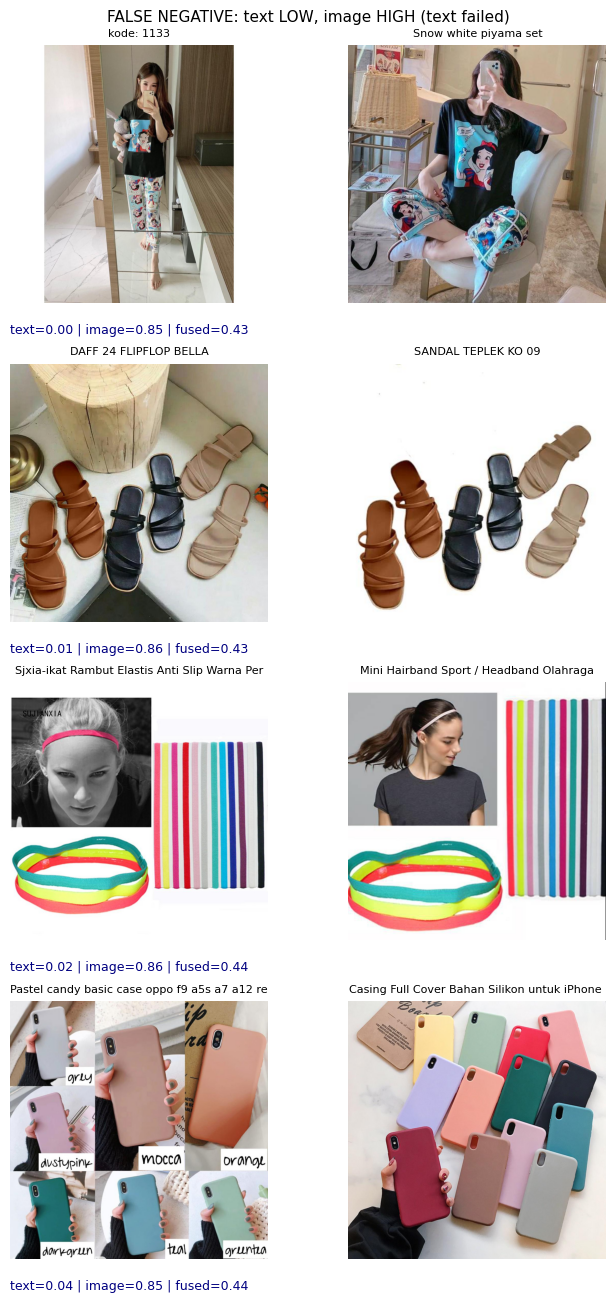

FALSE NEGATIVE: BOTH low (hardest): 3565 pairs


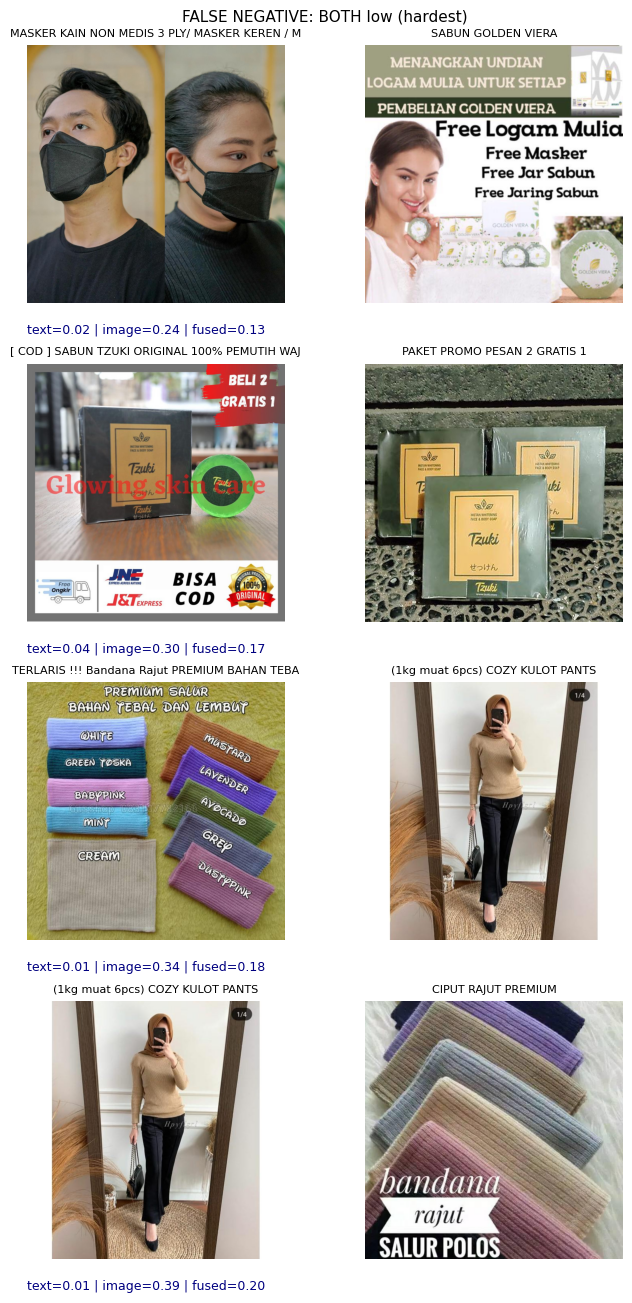

In [19]:
def show_pairs(T, header, n=4):
    T = T.head(n)
    fig, axes = plt.subplots(len(T), 2, figsize=(7, 3.3 * len(T)), squeeze=False)
    for k, (_, r) in enumerate(T.iterrows()):
        for c, side in enumerate(["i", "j"]):
            axes[k, c].imshow(load_img(IMG_DIR, r[f"img_{side}"])); axes[k, c].axis("off")
            axes[k, c].set_title(r[f"title_{side}"][:45], fontsize=8)
        axes[k, 0].text(0, -0.12, f"text={r.s_text:.2f} | image={r.s_img:.2f} | fused={r.s_fused:.2f}",
                        transform=axes[k, 0].transAxes, fontsize=9, color="navy")
    fig.suptitle(header, fontsize=11); plt.tight_layout(); plt.show()

cases = {
    "FALSE POSITIVE: text HIGH, image LOW (text misleads)":   FP[FP.text_high & ~FP.img_high],
    "FALSE POSITIVE: text LOW, image HIGH (image misleads)":  FP[~FP.text_high & FP.img_high],
    "FALSE POSITIVE: BOTH high (near-identical variants)":    FP[FP.text_high & FP.img_high],
    "FALSE NEGATIVE: text HIGH, image LOW (image failed)":    FN[FN.text_high & ~FN.img_high],
    "FALSE NEGATIVE: text LOW, image HIGH (text failed)":     FN[~FN.text_high & FN.img_high],
    "FALSE NEGATIVE: BOTH low (hardest)":                     FN[~FN.text_high & ~FN.img_high],
}
for name, T in cases.items():
    print(f"{name}: {len(T)} pairs")
    if len(T):
        show_pairs(T.sort_values("s_fused", ascending=name.startswith("FALSE NEGATIVE")), name)

In [20]:
cfg = dict(seed=SEED, n_images=int(len(df)), val_listings=int(len(va_idx)), test_listings=int(len(te_idx)),
           final=FINAL, test_metrics={k: round(v, 4) for k, v in final_metrics.items()},
           models=dict(text_embedding="paraphrase-multilingual-MiniLM-L12-v2 (384d)", image_embedding="clip-ViT-B-32 (512d)",
                       tfidf_char="char_wb 2-4, min_df=2", tfidf_word="unigram, sublinear_tf"),
           metric="mean per-listing F1 (Kaggle-style), predicted set = score>=thr", thr_grid="0.30-0.98 step 0.02",
           extraction_time_s=TIMES)
json.dump(cfg, open(f"{RES_DIR}/config.json", "w"), indent=2)
print(json.dumps(cfg, indent=2))

{
  "seed": 42,
  "n_images": 10001,
  "val_listings": 4880,
  "test_listings": 5121,
  "final": {
    "text": "char",
    "w": 0.5,
    "phash": true,
    "thr": 0.6
  },
  "test_metrics": {
    "precision": 0.9194,
    "recall": 0.8471,
    "f1": 0.8478
  },
  "models": {
    "text_embedding": "paraphrase-multilingual-MiniLM-L12-v2 (384d)",
    "image_embedding": "clip-ViT-B-32 (512d)",
    "tfidf_char": "char_wb 2-4, min_df=2",
    "tfidf_word": "unigram, sublinear_tf"
  },
  "metric": "mean per-listing F1 (Kaggle-style), predicted set = score>=thr",
  "thr_grid": "0.30-0.98 step 0.02",
  "extraction_time_s": {
    "minilm_text": 69.3,
    "clip_vitb32_img": 712.0
  }
}
